In [9]:
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

from src.model import *
from src.utils import *
from src.dataset import *

import matplotlib.pyplot as plt 

import torch
from torch.utils.data import DataLoader

In [10]:
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initiate model with same hyperparameters
osc_branch_net = General_MLP(input_size  = 2, 
                             output_size = 50,
                             depth       = 4, 
                             hidden_size = 32, 
                             act         = nn.Tanh())

osc_trunk_net  = General_MLP(input_size  = 1, 
                             output_size = 50,
                             depth       = 4, 
                             hidden_size = 32, 
                             act         = nn.Tanh())

osc_deepONet   = DeepONet(branch_net  = osc_branch_net, 
                          trunk_net   = osc_trunk_net,
                          output_size = 1)

# 2. Load the saved weights into the model

state_dict = torch.load("/home/enricp/repos/PINNS/weights/best_1d_osc.pth", map_location=device)
osc_deepONet.load_state_dict(state_dict)
osc_deepONet = osc_deepONet.to(device)

# 3. Set to eval mode
osc_deepONet.eval()



# Initialize Harmonic Oscillator object

string_constant = 2
dampening_coeff = 0.1
args1           = [string_constant, dampening_coeff]

osc_sampler     = LatinHypercubeSampler(dimensions = 2, 
                                        lows       = [-1, -1], 
                                        highs      = [1, 1])

osc_object          = harm_osc(args1)



In [12]:
dataset_size = 1001
batch_size   = 1
num_workers  = 8
t_span       = (0, 10)

osc_dataset = ODEIterableDataset(size          = dataset_size,
                                 system_class  = osc_object,
                                 sampler       = osc_sampler,
                                 t_span        = t_span,
                                 full_solution = True)

osc_loader  = DataLoader(dataset     = osc_dataset,
                         batch_size  = batch_size,
                         num_workers = num_workers)


In [13]:
# Single Sample for plotting
I, t, y = next(iter(osc_loader))

# Take first sample from batch
I = I[0]  # (2,)
t = t[0]  # (N,)
y = y[0]  # (N, 2) or (N,)

with torch.no_grad():
    t_tensor  = t.unsqueeze(1).to(device)          # (N, 1)
    u0_tensor = I.unsqueeze(0).expand(len(t), -1)  # (N, 2)
    u0_tensor = u0_tensor.to(device)

    model_sol = osc_deepONet(u0_tensor, t_tensor)  # (N, 1)
    model_sol = model_sol.cpu().numpy()


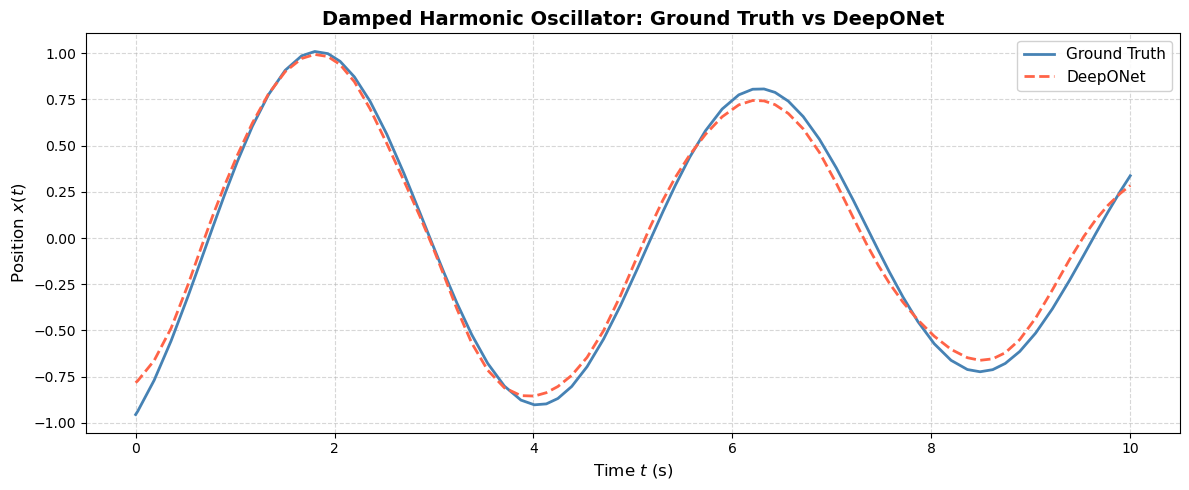

In [ ]:
# Plotting 

plt.figure(figsize=(12, 5))
plt.plot(t, y[0], color="steelblue", lw=2, label="Ground Truth")
plt.plot(t, model_sol, color="tomato",    lw=2, label="DeepONet", linestyle="--")
plt.title("Damped Harmonic Oscillator: Ground Truth vs DeepONet", fontsize=14, fontweight="bold")
plt.ylabel("Position $x(t)$", fontsize=12)
plt.xlabel("Time $t$ (s)", fontsize=12)
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()